In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/data-bank.csv')

In [ ]:
df.head()

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

## EDA

In [ ]:
# Explorasi data dasar
print("Shape dataset:", df.shape)
print("\nInfo dataset:")
print(df.info())
print("\nStatistik deskriptif:")
print(df.describe())
print("\nDistribusi target variable:")
print(df['Bankrupt?'].value_counts())
print("\nProporsi target variable:")
print(df['Bankrupt?'].value_counts(normalize=True))

Shape dataset: (6819, 96)

Info dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6819 entries, 0 to 6818
Data columns (total 96 columns):
 #   Column                                                    Non-Null Count  Dtype  
---  ------                                                    --------------  -----  
 0   Bankrupt?                                                 6819 non-null   int64  
 1    ROA(C) before interest and depreciation before interest  6819 non-null   float64
 2    ROA(A) before interest and % after tax                   6819 non-null   float64
 3    ROA(B) before interest and depreciation after tax        6819 non-null   float64
 4    Operating Gross Margin                                   6819 non-null   float64
 5    Realized Sales Gross Margin                              6819 non-null   float64
 6    Operating Profit Rate                                    6819 non-null   float64
 7    Pre-tax net Interest Rate                                6819 n

In [ ]:
# Cek total missing values per kolom
print("Missing Values per Kolom:")
print(df.isnull().sum())

# Cek total missing values di seluruh dataset
total_missing = df.isnull().sum().sum()
print(f"\nTotal Missing Values: {total_missing}")

Missing Values per Kolom:
Bankrupt?                                                   0
 ROA(C) before interest and depreciation before interest    0
 ROA(A) before interest and % after tax                     0
 ROA(B) before interest and depreciation after tax          0
 Operating Gross Margin                                     0
                                                           ..
 Liability to Equity                                        0
 Degree of Financial Leverage (DFL)                         0
 Interest Coverage Ratio (Interest expense to EBIT)         0
 Net Income Flag                                            0
 Equity to Liability                                        0
Length: 96, dtype: int64

Total Missing Values: 0


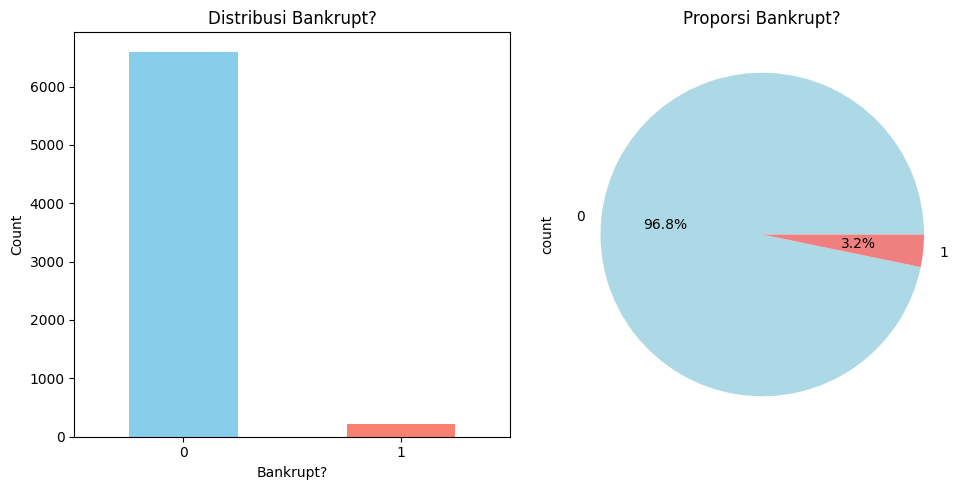

In [ ]:
# Visualisasi distribusi target variable
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
df['Bankrupt?'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Distribusi Bankrupt?')
plt.xlabel('Bankrupt?')
plt.ylabel('Count')
plt.xticks(rotation=0)

plt.subplot(1, 2, 2)
df['Bankrupt?'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['lightblue', 'lightcoral'])
plt.title('Proporsi Bankrupt?')

plt.tight_layout()
plt.show()

In [ ]:
# Analisis korelasi dengan target variable
correlations = df.corr()['Bankrupt?'].sort_values(ascending=False)
print("10 fitur dengan korelasi positif tertinggi:")
print(correlations.head(10))

10 fitur dengan korelasi positif tertinggi:
Bankrupt?                               1.000000
 Debt ratio %                           0.250161
 Current Liability to Assets            0.194494
 Borrowing dependency                   0.176543
 Current Liability to Current Assets    0.171306
 Liability to Equity                    0.166812
 Current Liabilities/Equity             0.153828
 Current Liability to Equity            0.153828
 Liability-Assets Flag                  0.139212
 Total expense/Assets                   0.139049
Name: Bankrupt?, dtype: float64


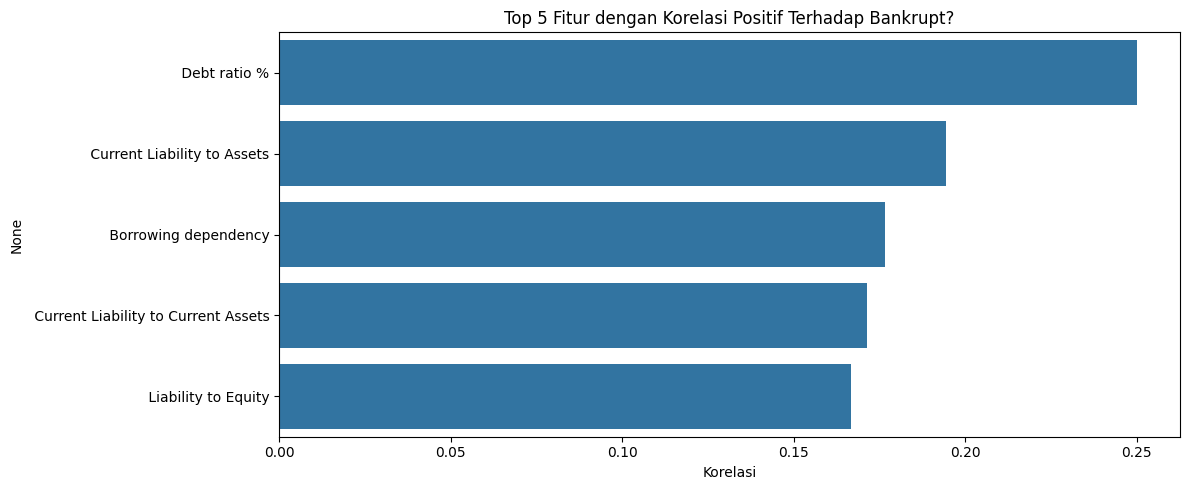

In [ ]:
# Visualisasi korelasi top 5
plt.figure(figsize=(12, 5))
top_features = correlations.drop('Bankrupt?').head(5)
sns.barplot(x=top_features.values, y=top_features.index)
plt.title('Top 5 Fitur dengan Korelasi Positif Terhadap Bankrupt?')
plt.xlabel('Korelasi')
plt.tight_layout()
plt.show()

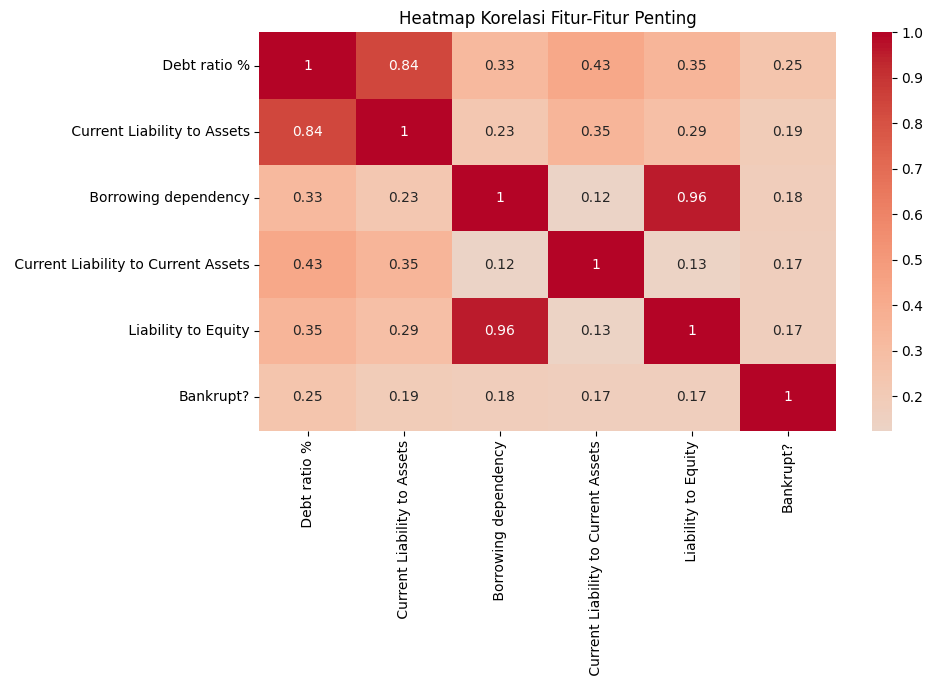

In [ ]:
# Heatmap korelasi untuk fitur-fitur penting
selected_features = list(top_features.index[:8]) + ['Bankrupt?']
plt.figure(figsize=(10, 7))
sns.heatmap(df[selected_features].corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Heatmap Korelasi Fitur-Fitur Penting')
plt.tight_layout()
plt.show()

## Data Preparation

In [ ]:
# 3. Data Preparation
X = df.drop('Bankrupt?', axis=1)
y = df['Bankrupt?']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n=== DATA SPLITTING ===")
print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Distribusi training - Tidak Bangkrut: {sum(y_train == 0)}, Bangkrut: {sum(y_train == 1)}")
print(f"Distribusi test - Tidak Bangkrut: {sum(y_test == 0)}, Bangkrut: {sum(y_test == 1)}")

# Standardisasi fitur
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\n=== SETELAH STANDARDISASI ===")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")


=== DATA SPLITTING ===
Training set: (5455, 95)
Test set: (1364, 95)
Distribusi training - Tidak Bangkrut: 5279, Bangkrut: 176
Distribusi test - Tidak Bangkrut: 1320, Bangkrut: 44

=== SETELAH STANDARDISASI ===
X_train_scaled shape: (5455, 95)
X_test_scaled shape: (1364, 95)


## Modelling

### 1. Base Model

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Models
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    'Logistic Regression': LogisticRegression(random_state=42, class_weight='balanced'),
    'SVM': SVC(random_state=42, class_weight='balanced', probability=True),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss'),
    'LightGBM': LGBMClassifier(n_estimators=100, random_state=42, verbose=-1),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    'Extra Trees': ExtraTreesClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    'Gaussian Naive Bayes': GaussianNB()
}

# Evaluasi model
results = {}

for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"Training {name}")
    print(f"{'='*50}")

    try:
        # Pipeline dengan SMOTE
        pipeline = Pipeline([
            ('smote', SMOTE(random_state=42)),
            ('classifier', model)
        ])

        # Training
        pipeline.fit(X_train_scaled, y_train)

        # Prediction
        y_pred = pipeline.predict(X_test_scaled)
        y_pred_proba = pipeline.predict_proba(X_test_scaled)

        # Metrics
        cm = confusion_matrix(y_test, y_pred)
        precision_0 = cm[0,0] / (cm[0,0] + cm[1,0]) if (cm[0,0] + cm[1,0]) > 0 else 0
        precision_1 = cm[1,1] / (cm[1,1] + cm[0,1]) if (cm[1,1] + cm[0,1]) > 0 else 0
        accuracy = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)

        results[name] = {
            'model': pipeline,
            'precision_0': precision_0,
            'precision_1': precision_1,
            'accuracy': accuracy,
            'f1_score': f1,
            'recall': recall,
            'confusion_matrix': cm
        }

        print(f"Confusion Matrix:\n{cm}")
        print(f"Precision Class 0 (Tidak Bangkrut): {precision_0:.4f}")
        print(f"Precision Class 1 (Bangkrut): {precision_1:.4f}")
        print(f"Accuracy: {accuracy:.4f}")
        print(f"F1-Score: {f1:.4f}")
        print(f"Recall: {recall:.4f}")
        print(f"Classification Report:\n{classification_report(y_test, y_pred)}")

    except Exception as e:
        print(f"Error training {name}: {e}")
        continue

# Tampilkan summary hasil semua model
print(f"\n{'='*60}")
print("SUMMARY SEMUA MODEL")
print(f"{'='*60}")

summary_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [results[name]['accuracy'] for name in results.keys()],
    'F1-Score': [results[name]['f1_score'] for name in results.keys()],
    'Recall': [results[name]['recall'] for name in results.keys()],
    'Precision_0': [results[name]['precision_0'] for name in results.keys()],
    'Precision_1': [results[name]['precision_1'] for name in results.keys()]
}).sort_values('F1-Score', ascending=False)

print(summary_df.round(4))


Training Random Forest
Confusion Matrix:
[[1283   37]
 [  18   26]]
Precision Class 0 (Tidak Bangkrut): 0.9862
Precision Class 1 (Bangkrut): 0.4127
Accuracy: 0.9597
F1-Score: 0.4860
Recall: 0.5909
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1320
           1       0.41      0.59      0.49        44

    accuracy                           0.96      1364
   macro avg       0.70      0.78      0.73      1364
weighted avg       0.97      0.96      0.96      1364


Training Logistic Regression
Confusion Matrix:
[[1172  148]
 [  10   34]]
Precision Class 0 (Tidak Bangkrut): 0.9915
Precision Class 1 (Bangkrut): 0.1868
Accuracy: 0.8842
F1-Score: 0.3009
Recall: 0.7727
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.89      0.94      1320
           1       0.19      0.77      0.30        44

    accuracy                           0.88      1364
   macr

### 2. Tuning Manual 5 Model Terbaik Berdasarkan Base Model

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Hyperparameter tuning manual untuk setiap model
models_tuned = {
    'LightGBM': [
        LGBMClassifier(n_estimators=100, random_state=42, verbose=-1),
        LGBMClassifier(n_estimators=200, learning_rate=0.1, random_state=42, verbose=-1),
        LGBMClassifier(n_estimators=150, max_depth=10, random_state=42, verbose=-1),
        LGBMClassifier(n_estimators=100, learning_rate=0.05, num_leaves=31, random_state=42, verbose=-1)
    ],
    'Random Forest': [
        RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
        RandomForestClassifier(n_estimators=200, max_depth=15, random_state=42, class_weight='balanced'),
        RandomForestClassifier(n_estimators=150, min_samples_split=5, random_state=42, class_weight='balanced'),
        RandomForestClassifier(n_estimators=100, max_features='sqrt', random_state=42, class_weight='balanced')
    ],
    'XGBoost': [
        XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss'),
        XGBClassifier(n_estimators=200, learning_rate=0.1, random_state=42, eval_metric='logloss'),
        XGBClassifier(n_estimators=150, max_depth=8, random_state=42, eval_metric='logloss'),
        XGBClassifier(n_estimators=100, subsample=0.8, random_state=42, eval_metric='logloss')
    ],
    'Gradient Boosting': [
        GradientBoostingClassifier(n_estimators=100, random_state=42),
        GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, random_state=42),
        GradientBoostingClassifier(n_estimators=150, max_depth=5, random_state=42),
        GradientBoostingClassifier(n_estimators=100, subsample=0.8, random_state=42)
    ],
    'Extra Trees': [
        ExtraTreesClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
        ExtraTreesClassifier(n_estimators=200, random_state=42, class_weight='balanced'),
        ExtraTreesClassifier(n_estimators=150, max_depth=15, random_state=42, class_weight='balanced')
    ]
}

# Evaluasi model dengan hyperparameter tuning
results_tuned = {}

for model_name, model_list in models_tuned.items():
    print(f"\n{'='*60}")
    print(f"HYPERPARAMETER TUNING - {model_name}")
    print(f"{'='*60}")

    best_f1 = 0
    best_model = None
    best_params = {}

    for i, model in enumerate(model_list):
        print(f"\n--- Kombinasi {i+1} ---")

        try:
            # Pipeline dengan SMOTE
            pipeline = Pipeline([
                ('smote', SMOTE(random_state=42)),
                ('classifier', model)
            ])

            # Training
            pipeline.fit(X_train_scaled, y_train)

            # Prediction
            y_pred = pipeline.predict(X_test_scaled)

            # Metrics
            accuracy = accuracy_score(y_test, y_pred)
            f1 = f1_score(y_test, y_pred)
            recall = recall_score(y_test, y_pred)
            precision = precision_score(y_test, y_pred)

            # Get parameters
            params = model.get_params()

            print(f"Parameters: { {k: v for k, v in params.items() if k in ['n_estimators', 'learning_rate', 'max_depth', 'min_samples_split', 'max_features', 'subsample', 'num_leaves']} }")
            print(f"Accuracy: {accuracy:.4f}, F1-Score: {f1:.4f}, Recall: {recall:.4f}, Precision: {precision:.4f}")

            # Update best model
            if f1 > best_f1:
                best_f1 = f1
                best_model = pipeline
                best_params = params

        except Exception as e:
            print(f"Error: {e}")
            continue

    # Simpan best model untuk setiap algoritma
    if best_model is not None:
        y_pred = best_model.predict(X_test_scaled)
        cm = confusion_matrix(y_test, y_pred)
        precision_0 = cm[0,0] / (cm[0,0] + cm[1,0]) if (cm[0,0] + cm[1,0]) > 0 else 0
        precision_1 = cm[1,1] / (cm[1,1] + cm[0,1]) if (cm[1,1] + cm[0,1]) > 0 else 0
        accuracy = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)

        results_tuned[model_name] = {
            'model': best_model,
            'best_params': best_params,
            'precision_0': precision_0,
            'precision_1': precision_1,
            'accuracy': accuracy,
            'f1_score': f1,
            'recall': recall,
            'confusion_matrix': cm
        }

        print(f"\n✅ BEST {model_name}:")
        print(f"Best F1-Score: {best_f1:.4f}")
        print(f"Best Parameters: { {k: v for k, v in best_params.items() if k in ['n_estimators', 'learning_rate', 'max_depth', 'min_samples_split', 'max_features', 'subsample', 'num_leaves']} }")

# Tampilkan summary hasil tuning
print(f"\n{'='*70}")
print("SUMMARY HYPERPARAMETER TUNING")
print(f"{'='*70}")

if results_tuned:
    summary_tuned_df = pd.DataFrame({
        'Model': list(results_tuned.keys()),
        'Accuracy': [results_tuned[name]['accuracy'] for name in results_tuned.keys()],
        'F1-Score': [results_tuned[name]['f1_score'] for name in results_tuned.keys()],
        'Recall': [results_tuned[name]['recall'] for name in results_tuned.keys()],
        'Precision_0': [results_tuned[name]['precision_0'] for name in results_tuned.keys()],
        'Precision_1': [results_tuned[name]['precision_1'] for name in results_tuned.keys()]
    }).sort_values('F1-Score', ascending=False)

    print(summary_tuned_df.round(4))

    # Bandingkan dengan model baseline
    print(f"\n{'='*70}")
    print("PERBANDINGAN SEBELUM & SETELAH TUNING")
    print(f"{'='*70}")

    # Ambil hasil baseline dari model sebelumnya
    baseline_f1 = {
        'LightGBM': 0.5208,
        'Random Forest': 0.4860,
        'XGBoost': 0.4792,
        'Gradient Boosting': 0.4167,
        'Extra Trees': 0.4330
    }

    comparison_data = []
    for model_name in summary_tuned_df['Model']:
        tuned_f1 = summary_tuned_df[summary_tuned_df['Model'] == model_name]['F1-Score'].values[0]
        baseline_f1_score = baseline_f1.get(model_name, 0)
        improvement = tuned_f1 - baseline_f1_score

        comparison_data.append({
            'Model': model_name,
            'Baseline_F1': baseline_f1_score,
            'Tuned_F1': tuned_f1,
            'Improvement': improvement
        })

    comparison_df = pd.DataFrame(comparison_data).sort_values('Improvement', ascending=False)
    print(comparison_df.round(4))

else:
    print("Tidak ada model yang berhasil di-tuning")


HYPERPARAMETER TUNING - LightGBM

--- Kombinasi 1 ---
Parameters: {'learning_rate': 0.1, 'max_depth': -1, 'n_estimators': 100, 'num_leaves': 31, 'subsample': 1.0}
Accuracy: 0.9663, F1-Score: 0.5208, Recall: 0.5682, Precision: 0.4808

--- Kombinasi 2 ---
Parameters: {'learning_rate': 0.1, 'max_depth': -1, 'n_estimators': 200, 'num_leaves': 31, 'subsample': 1.0}
Accuracy: 0.9685, F1-Score: 0.5169, Recall: 0.5227, Precision: 0.5111

--- Kombinasi 3 ---
Parameters: {'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 150, 'num_leaves': 31, 'subsample': 1.0}
Accuracy: 0.9707, F1-Score: 0.5556, Recall: 0.5682, Precision: 0.5435

--- Kombinasi 4 ---
Parameters: {'learning_rate': 0.05, 'max_depth': -1, 'n_estimators': 100, 'num_leaves': 31, 'subsample': 1.0}
Accuracy: 0.9567, F1-Score: 0.4779, Recall: 0.6136, Precision: 0.3913

✅ BEST LightGBM:
Best F1-Score: 0.5556
Best Parameters: {'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 150, 'num_leaves': 31, 'subsample': 1.0}

HYPERPARAM

## Evaluasi

In [ ]:
# EVALUASI MODEL TERBAIK
print("=" * 80)
print("EVALUASI KOMPREHENSIF MODEL BANKRUPTCY PREDICTION")
print("=" * 80)

# Cek dulu apa yang ada di results_tuned
if 'results_tuned' not in locals() or not results_tuned:
    print("Menggunakan results dari base model...")
    best_models = {
        'LightGBM': results['LightGBM'],
        'Random Forest': results['Random Forest'],
        'XGBoost': results['XGBoost']
    }
else:
    # Model terbaik berdasarkan F1-Score dari results_tuned
    best_models = {
        'XGBoost': results_tuned['XGBoost'],
        'LightGBM': results_tuned['LightGBM'],
        'Random Forest': results_tuned['Random Forest']
    }

# Evaluasi masing-masing model
for name, result in best_models.items():
    print(f"\n{'='*60}")
    print(f"EVALUASI {name}")
    print(f"{'='*60}")

    model = result['model']

    # Pastikan kita menggunakan data yang benar untuk prediction
    y_pred = model.predict(X_test_scaled)

    # Hitung ulang metrics untuk memastikan konsistensi
    from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report

    cm = confusion_matrix(y_test, y_pred)

    # Handle confusion matrix dengan cara yang aman
    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
    else:
        # Jika confusion matrix tidak 2x2, handle secara manual
        if cm.shape[0] == 1 and cm.shape[1] == 2:
            # Hanya satu kelas yang terprediksi
            if y_test.unique()[0] == 0:
                tn, fp, fn, tp = cm[0,0], cm[0,1], 0, 0
            else:
                tn, fp, fn, tp = 0, 0, cm[0,0], cm[0,1]
        elif cm.shape[0] == 2 and cm.shape[1] == 1:
            # Hanya satu kelas yang ada di prediksi
            if y_pred.unique()[0] == 0:
                tn, fp, fn, tp = cm[0,0], 0, cm[1,0], 0
            else:
                tn, fp, fn, tp = 0, cm[0,0], 0, cm[1,0]
        else:
            print(f"Warning: Confusion matrix shape tidak expected: {cm.shape}")
            # Default values
            tn, fp, fn, tp = 0, 0, 0, 0

    print(f"Confusion Matrix (shape: {cm.shape}):")
    print(cm)
    print()
    print(f"                Predicted 0   Predicted 1")
    print(f"Actual 0 (Sehat)    {tn:4d} (TN)      {fp:4d} (FP)")
    print(f"Actual 1 (Bangkrut) {fn:4d} (FN)      {tp:4d} (TP)")
    print()

    # Calculate all metrics dengan error handling
    accuracy = accuracy_score(y_test, y_pred)

    # Precision dan Recall dengan handling division by zero
    try:
        precision_1 = precision_score(y_test, y_pred, zero_division=0)
    except:
        precision_1 = tp / (tp + fp) if (tp + fp) > 0 else 0

    try:
        recall_1 = recall_score(y_test, y_pred, zero_division=0)
    except:
        recall_1 = tp / (tp + fn) if (tp + fn) > 0 else 0

    try:
        f1 = f1_score(y_test, y_pred, zero_division=0)
    except:
        f1 = 2 * (precision_1 * recall_1) / (precision_1 + recall_1) if (precision_1 + recall_1) > 0 else 0

    # Precision untuk class 0
    precision_0 = tn / (tn + fn) if (tn + fn) > 0 else 0

    # Additional Metrics dengan error handling
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0  # True Negative Rate
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0  # False Negative Rate
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0  # False Positive Rate

    print("METRIC PERFORMANCE:")
    print(f"Accuracy:           {accuracy:.4f}")
    print(f"F1-Score:           {f1:.4f}")
    print()
    print(f"KELAS 1 - BANGRUT (Positive):")
    print(f"Precision:          {precision_1:.4f}  → Dari yg diprediksi bangkrut, {precision_1*100:.1f}% benar bangkrut")
    print(f"Recall (Sensitivity): {recall_1:.4f}  → Dari yg benar bangkrut, {recall_1*100:.1f}% terdeteksi")
    print(f"False Negative Rate: {fnr:.4f}  → {fnr*100:.1f}% bangkrut tidak terdeteksi")
    print()
    print(f"KELAS 0 - SEHAT (Negative):")
    print(f"Precision:          {precision_0:.4f}  → Dari yg diprediksi sehat, {precision_0*100:.1f}% benar sehat")
    print(f"Specificity:        {specificity:.4f}  → Dari yg benar sehat, {specificity*100:.1f}% terdeteksi sehat")
    print(f"False Positive Rate: {fpr:.4f}  → {fpr*100:.1f}% sehat dikira bangkrut")
    print()

    # Business Impact Analysis
    total_samples = len(y_test)
    actual_bankrupt = sum(y_test == 1)
    actual_healthy = sum(y_test == 0)

    print("BUSINESS IMPACT ANALYSIS:")
    print(f"Total Sample Test:    {total_samples}")
    print(f"Perusahaan Bangkrut:  {actual_bankrupt} ({actual_bankrupt/total_samples*100:.1f}%)")
    print(f"Perusahaan Sehat:     {actual_healthy} ({actual_healthy/total_samples*100:.1f}%)")
    print()
    print(f"RISIKO:")
    print(f"- Perusahaan bangkrut yg TIDAK terdeteksi: {fn} perusahaan")
    print(f"- Perusahaan sehat yg dikira bangkrut:     {fp} perusahaan")

    # Classification Report
    print(f"\n📋 CLASSIFICATION REPORT:")
    print(classification_report(y_test, y_pred, target_names=['Sehat (0)', 'Bangkrut (1)'], zero_division=0))

    # Update results dictionary dengan metrics yang sudah dihitung ulang
    best_models[name].update({
        'accuracy': accuracy,
        'precision_0': precision_0,
        'precision_1': precision_1,
        'recall': recall_1,
        'f1_score': f1,
        'confusion_matrix': cm,
        'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp
    })

# PERBANDINGAN SEMUA MODEL
print("\n" + "="*80)
print("PERBANDINGAN SEMUA MODEL TERBAIK")
print("="*80)

comparison_data = []
for name, result in best_models.items():
    # Hitung rates dengan error handling
    fn_rate = result['fn'] / (result['fn'] + result['tp']) if (result['fn'] + result['tp']) > 0 else 0
    fp_rate = result['fp'] / (result['fp'] + result['tn']) if (result['fp'] + result['tn']) > 0 else 0

    comparison_data.append({
        'Model': name,
        'Accuracy': result['accuracy'],
        'F1-Score': result['f1_score'],
        'Precision_1': result['precision_1'],
        'Recall_1': result['recall'],
        'Precision_0': result['precision_0'],
        'TN': result['tn'],
        'FP': result['fp'],
        'FN': result['fn'],
        'TP': result['tp'],
        'False_Negative_Rate': fn_rate,
        'False_Positive_Rate': fp_rate
    })

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.round(4)

# Tampilkan comparison table dengan formatting yang baik
pd.set_option('display.width', 1000)
pd.set_option('display.max_columns', 15)
print(comparison_df.to_string(index=False))

# SUMMARY REKOMENDASI
print("\n" + "="*80)
print("SUMMARY REKOMENDASI FINAL")
print("="*80)

# Cari model terbaik berdasarkan F1-Score
if not comparison_df.empty and 'F1-Score' in comparison_df.columns:
    best_model_name = comparison_df.loc[comparison_df['F1-Score'].idxmax(), 'Model']
    best_model_result = best_models[best_model_name]

    print(f"🏆 MODEL TERBAIK: {best_model_name}")
    print(f"📈 F1-Score: {best_model_result['f1_score']:.4f}")
    print(f"🎯 Recall Bangkrut: {best_model_result['recall']:.4f}")
    print(f"✅ Precision Bangkrut: {best_model_result['precision_1']:.4f}")
else:
    print("Tidak bisa menentukan model terbaik - data tidak tersedia")

EVALUASI KOMPREHENSIF MODEL BANKRUPTCY PREDICTION

EVALUASI XGBoost
Confusion Matrix (shape: (2, 2)):
[[1293   27]
 [  16   28]]

                Predicted 0   Predicted 1
Actual 0 (Sehat)    1293 (TN)        27 (FP)
Actual 1 (Bangkrut)   16 (FN)        28 (TP)

METRIC PERFORMANCE:
Accuracy:           0.9685
F1-Score:           0.5657

KELAS 1 - BANGRUT (Positive):
Precision:          0.5091  → Dari yg diprediksi bangkrut, 50.9% benar bangkrut
Recall (Sensitivity): 0.6364  → Dari yg benar bangkrut, 63.6% terdeteksi
False Negative Rate: 0.3636  → 36.4% bangkrut tidak terdeteksi

KELAS 0 - SEHAT (Negative):
Precision:          0.9878  → Dari yg diprediksi sehat, 98.8% benar sehat
Specificity:        0.9795  → Dari yg benar sehat, 98.0% terdeteksi sehat
False Positive Rate: 0.0205  → 2.0% sehat dikira bangkrut

BUSINESS IMPACT ANALYSIS:
Total Sample Test:    1364
Perusahaan Bangkrut:  44 (3.2%)
Perusahaan Sehat:     1320 (96.8%)

RISIKO:
- Perusahaan bangkrut yg TIDAK terdeteksi: 16 perus

Error dalam visualisasi: index 3 is out of bounds for axis 1 with size 3
Melanjutkan tanpa visualisasi...


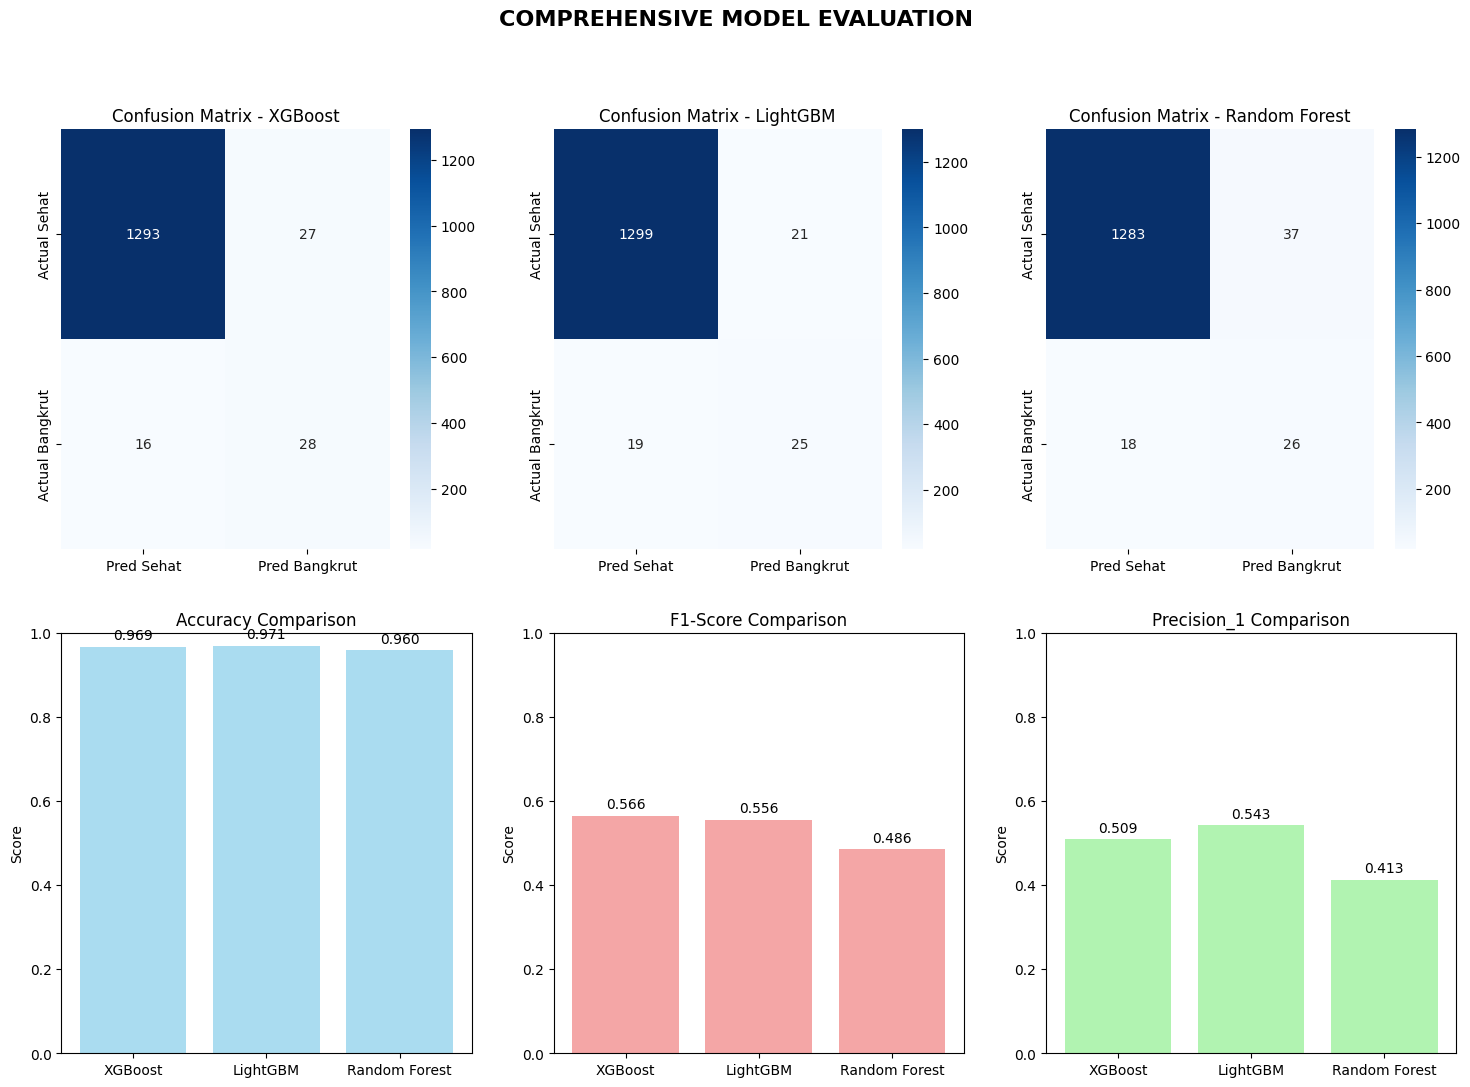

In [ ]:
# VISUALISASI COMPREHENSIF
try:
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('COMPREHENSIVE MODEL EVALUATION', fontsize=16, fontweight='bold')

    # 1. Confusion Matrix
    for idx, (name, result) in enumerate(best_models.items()):
        cm = result['confusion_matrix']
        ax = axes[0, idx]

        # Pastikan confusion matrix bisa diplot
        if cm.shape == (2, 2):
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                        xticklabels=['Pred Sehat', 'Pred Bangkrut'],
                        yticklabels=['Actual Sehat', 'Actual Bangkrut'])
            ax.set_title(f'Confusion Matrix - {name}')
        else:
            ax.text(0.5, 0.5, f'Matrix Shape: {cm.shape}\nTidak bisa diplot',
                   ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f'Confusion Matrix - {name}')
            ax.set_xticks([])
            ax.set_yticks([])

    # 2. Metrics Comparison
    metrics_to_plot = ['Accuracy', 'F1-Score', 'Precision_1', 'Recall_1']
    colors = ['skyblue', 'lightcoral', 'lightgreen', 'gold']

    for i, metric in enumerate(metrics_to_plot):
        ax = axes[1, i]
        values = [comparison_df[comparison_df['Model'] == model][metric].values[0]
                 for model in best_models.keys()]

        bars = ax.bar(best_models.keys(), values, color=colors[i], alpha=0.7)
        ax.set_title(f'{metric} Comparison')
        ax.set_ylabel('Score')
        ax.set_ylim(0, 1)

        # Tambahkan nilai di atas bar
        for bar, value in zip(bars, values):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                   f'{value:.3f}', ha='center', va='bottom')

    # 3. Business Impact - False Rates
    ax = axes[1, 2]
    models_list = list(best_models.keys())
    fn_rates = [comparison_df[comparison_df['Model'] == model]['False_Negative_Rate'].values[0]
               for model in models_list]
    fp_rates = [comparison_df[comparison_df['Model'] == model]['False_Positive_Rate'].values[0]
               for model in models_list]

    x = range(len(models_list))
    width = 0.35
    ax.bar([i - width/2 for i in x], fn_rates, width, label='False Negative Rate', color='red', alpha=0.7)
    ax.bar([i + width/2 for i in x], fp_rates, width, label='False Positive Rate', color='orange', alpha=0.7)
    ax.set_title('Business Risk Analysis')
    ax.set_ylabel('Rate')
    ax.set_xticks(x)
    ax.set_xticklabels(models_list)
    ax.legend()

    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"Error dalam visualisasi: {e}")
    print("Melanjutkan tanpa visualisasi...")


📊 ROC ANALYSIS:


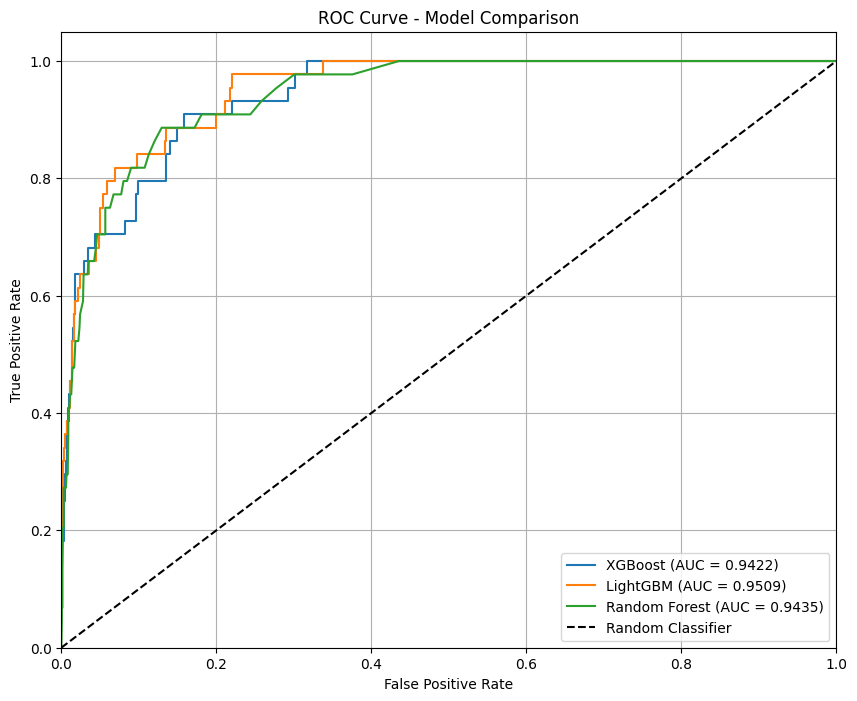

In [ ]:
# ROC Curve untuk model terbaik
print(f"\n📊 ROC ANALYSIS:")
try:
    from sklearn.metrics import roc_curve, auc

    plt.figure(figsize=(10, 6))
    for name, result in best_models.items():
        model = result['model']
        if hasattr(model, 'predict_proba'):
            y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
            fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
            roc_auc = auc(fpr, tpr)

            plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})')

    plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve - Model Comparison')
    plt.legend()
    plt.grid(True)
    plt.show()

except Exception as e:
    print(f"Error dalam ROC analysis: {e}")

## Feature Importance

TOP 5 FEATURE IMPORTANCE:
                                     Feature  Importance
39                      Borrowing dependency    0.221090
18   Persistent EPS in the Last Four Seasons    0.119246
9       Continuous interest rate (after tax)    0.061737
85                Net Income to Total Assets    0.026412
35                Total debt/Total net worth    0.024795


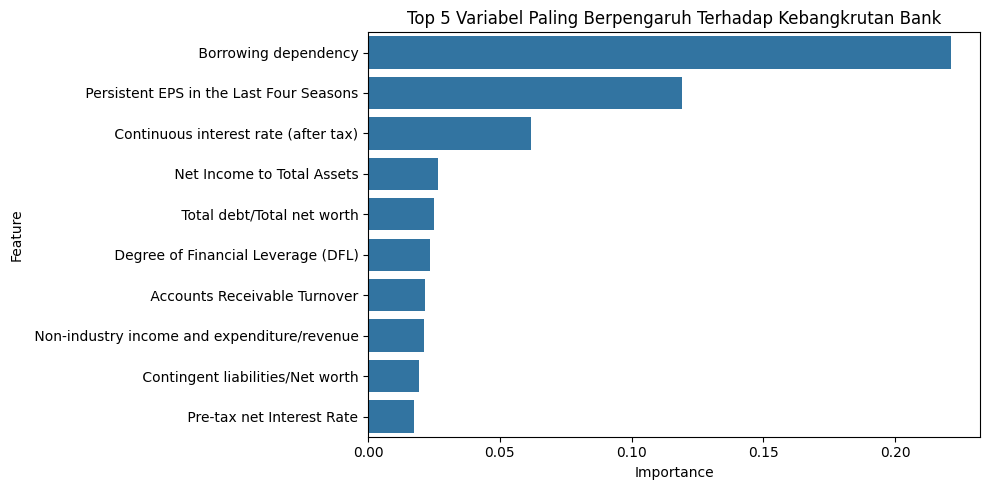

In [ ]:
# Dapatkan feature importance dari model terbaik
best_model = results_tuned['XGBoost']['model']
feature_importance = best_model.named_steps['classifier'].feature_importances_

# Match dengan nama feature
feature_names = X.columns
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

print("TOP 5 FEATURE IMPORTANCE:")
print(importance_df.head(5))

# Visualisasi
plt.figure(figsize=(10, 5))
sns.barplot(data=importance_df.head(10), x='Importance', y='Feature')
plt.title('Top 5 Variabel Paling Berpengaruh Terhadap Kebangkrutan Bank')
plt.tight_layout()
plt.show()